# Psi–Leaf-Water-Content slopes for blue oak — minimal reproduction

**Paper:** Boving, Allen, Brodrick, Chadwick, Trugman & Anderegg (2025). *The Unstable Relationship Between Drought Status and Leaf Water Content Complicates the Remote Sensing of Tree Drought Stress.* Global Change Biology 31(4):e70188, DOI 10.1111/gcb.70188 (open-access copy: PMC12007071).

**Author code:** `bovingi/mpa_lwc_lwa_cwc` tag **v2.0** = commit `fe5efc87404a174243dfec30631a354e0c6d1905` (Zenodo DOI 10.5281/zenodo.15110087, CC-BY-4.0). The analysis scripts are R Markdown; this notebook runs the exact author R code via `Rscript`.

**Scope (one minimal example):** the paper's Figure-2-style comparison of Ψ–LWmass slopes for blue oak (*Quercus douglasii*): **diel** (per-tree hydration) slopes, **spatial** slopes, **seasonal (temporal)** slopes — all bootstrapped as in the author's `3.1_BLUES_LWC.Rmd` — against laboratory **pressure–volume (PV) curve** slopes from `1_pvcurves.Rmd`. Also fits the paper's mixed-effects model `lmer(water_potential ~ lwc_mean + (lwc_mean|tree) + (lwc_mean|week) + (1|site))` (Table 2 family).

**Not reproduced:** AVIRIS-NG/ISOFIT CWC retrieval, dCWC remote-sensing analysis, variance decomposition, live-oak analyses, publication-figure styling.

**実行内容（日本語）:** ブルーオークの水ポテンシャル Ψ と葉含水量 LWmass の傾きを、日内（diel）・空間・季節（temporal）の各スケールで作者の R コードをそのまま実行してブートストラップ推定し、実験室の PV 曲線の傾きと比較します。混合モデル（Table 2 系）も当てはめます。CWC リモートセンシング解析は対象外です。

**Execution status:** this notebook is validated end-to-end on a fresh **CPU** Colab runtime (see the validation record at the end). No GPU is needed — the method is pure R statistics.

## 1 · Runtime

Select **Runtime → Change runtime type → CPU** (the default). No GPU is required; the heaviest step is ~600,000 tiny `lm()` fits inside the author's bootstrap loops (several minutes). Total expected wall time ≈ 15–25 min, dominated by R package installation (~5–10 min) and the bootstraps. Downloads ≈ 1 MB.

**実行環境（日本語）:** CPU ランタイムのみで動作します。GPU は不要です。所要時間の目安は 15–25 分（R パッケージ導入とブートストラップが主）。

Verify the Colab VM ships an R installation; this notebook uses Python only as a launcher for `Rscript` (the Colab CLI executes a Python kernel, but the scientific code is the authors' R).

In [ ]:
import subprocess, sys
print(subprocess.run(["lsb_release","-ds"], capture_output=True, text=True).stdout.strip())
r = subprocess.run(["Rscript","--version"], capture_output=True, text=True)
print(r.stderr.strip() or r.stdout.strip())
assert r.returncode == 0, 'Rscript not found on this runtime'

Ubuntu 24.04.5 LTS
Rscript (R) version 4.6.1 (2026-06-24)


## 2 · R package setup

Install the R packages the author scripts load for the reproduced path: `tidyverse`, `janitor`, `MetBrewer` (author `figure_info.R` theming), plus `lme4` and `arm` for the mixed model. Posit Package Manager precompiled binaries are used for the detected Ubuntu release to keep setup fast. Expect roughly 5–10 minutes on first run.

**日本語:** 作者のスクリプトが使う R パッケージを導入します（バイナリ取得で高速化）。初回は 5–10 分程度かかります。

In [ ]:
def run_r(path):
    import subprocess
    p = subprocess.run(['Rscript', path], capture_output=True, text=True)
    out = (p.stdout or '').strip().splitlines()
    err = (p.stderr or '').strip().splitlines()
    print(chr(10).join(out[-25:]))
    if p.returncode != 0:
        raise RuntimeError('R step ' + path + ' failed rc=' + str(p.returncode) + chr(10) + chr(10).join(err[-25:]))

Define a small helper that runs an R script and surfaces its output/errors in the notebook output.

In [ ]:
%%time
setup_r = r"""
codename <- readLines('/etc/os-release')
cn <- sub('.*VERSION_CODENAME=','', grep('VERSION_CODENAME', codename, value=TRUE))
options(repos = c(CRAN = sprintf('https://packagemanager.posit.co/cran/__linux__/%s/latest', cn)),
        HTTPUserAgent = sprintf('R/%s R (%s)', getRversion(), paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
install.packages(c('tidyverse','janitor','MetBrewer','lme4','arm','gridExtra'))
cat('installed:\n'); print(rownames(installed.packages()[rownames(installed.packages()) %in% c('tidyverse','janitor','MetBrewer','lme4','arm','gridExtra'),,drop=FALSE]))
"""
open('/content/setup.R','w').write(setup_r)
run_r('/content/setup.R')

installed:
[1] "arm"       "gridExtra" "janitor"   "lme4"      "MetBrewer" "tidyverse"
[7] "tidyverse"
CPU times: user 5.5 ms, sys: 2.42 ms, total: 7.92 ms
Wall time: 12.2 s


## 3 · Pinned input download

Download the author's data tables and theming helper from the pinned v2.0 commit (`fe5efc87404a174243dfec30631a354e0c6d1905`) and verify each file's Git blob SHA-1 and size before use:

- `processed-data/analysis_bothspp20230724.csv` — in-situ tree measurements (Ψ, `lwc_mean`, tree/week/time/site) for both oak species; the author script filters to *blue oak* (path preserved exactly as in the author v2.0 repository).
- `data/pv_shift_kk.csv` — pressure-volume curves (SHIFT 2022, K. Chadwick processing).
- `data/pv_curves_long_rayna.csv` — pressure-volume curves (July 2023 survey).
- `scripts/scripts_functions/figure_info.R` — author color scales/themes, included verbatim.

**日本語:** 作者リポジトリの pinned コミットから最小限の入力 CSV をダウンロードし、Git blob SHA-1 とサイズを検証します。

In [ ]:
import urllib.request, hashlib, pathlib

COMMIT = "fe5efc87404a174243dfec30631a354e0c6d1905"
BASE = f"https://raw.githubusercontent.com/bovingi/mpa_lwc_lwa_cwc/{COMMIT}"
# (path in repo, git blob sha1, expected bytes)
EXPECTED = [
    ("processed-data/analysis_bothspp20230724.csv", "caaddd1389aa86c6b5115ea6df670dc9a0a8f522", 293507),
    ("final_data/pv_shift_kk.csv",                  "39e69d35be5ac25c9908401bfa0a2dd388c2935b", 30955),
    ("final_data/pv_curves_long_rayna.csv",         "ada865ebec52d1daa68ddbf9d3b760779f99ae93", 81203),
    ("scripts/scripts_functions/figure_info.R",     "b317128c5de5acd9774767b5f042065287d1ddd3", 6248),
]
for rel, sha, size in EXPECTED:
    raw = urllib.request.urlopen(f"{BASE}/{urllib.request.quote(rel)}", timeout=120).read()
    assert len(raw) == size, (rel, len(raw), size)
    blob = hashlib.sha1(b"blob %d\0" % len(raw) + raw).hexdigest()
    assert blob == sha, (rel, blob, sha)
    dest = pathlib.Path("/content") / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(raw)
    print(f"OK  {rel}  {len(raw)} bytes  blob {blob[:12]}...")

OK  processed-data/analysis_bothspp20230724.csv  293507 bytes  blob caaddd1389aa...
OK  final_data/pv_shift_kk.csv  30955 bytes  blob 39e69d35be5a...


OK  final_data/pv_curves_long_rayna.csv  81203 bytes  blob ada865ebec52...
OK  scripts/scripts_functions/figure_info.R  6248 bytes  blob b317128c5de5...


## 4 · Data preparation and input preview (author code)

Run the author's data-preparation chunk from `3.1_BLUES_LWC.Rmd` verbatim (path helper adapted), then preview the actual inputs: sample counts per week/measurement time and the raw Ψ vs leaf-water-content scatter the author uses to open the diel analysis. **実行前に、実データのプレビューを表示します。**

rows: 595  trees: 49  weeks: 12 
# A tibble: 12 × 3
    week    md    pd
   <dbl> <int> <int>
 1     9     3    NA
 2    10    20    17
 3    11     9    12
 4    12    14    17
 5    14    20    40
 6    15    39    20
 7    17    38    36
 8    19    38    22
 9    21    39    40
10    29    36    33
11    33    19    16
12    37    36    31
CPU times: user 4.04 ms, sys: 1.13 ms, total: 5.17 ms
Wall time: 4.4 s


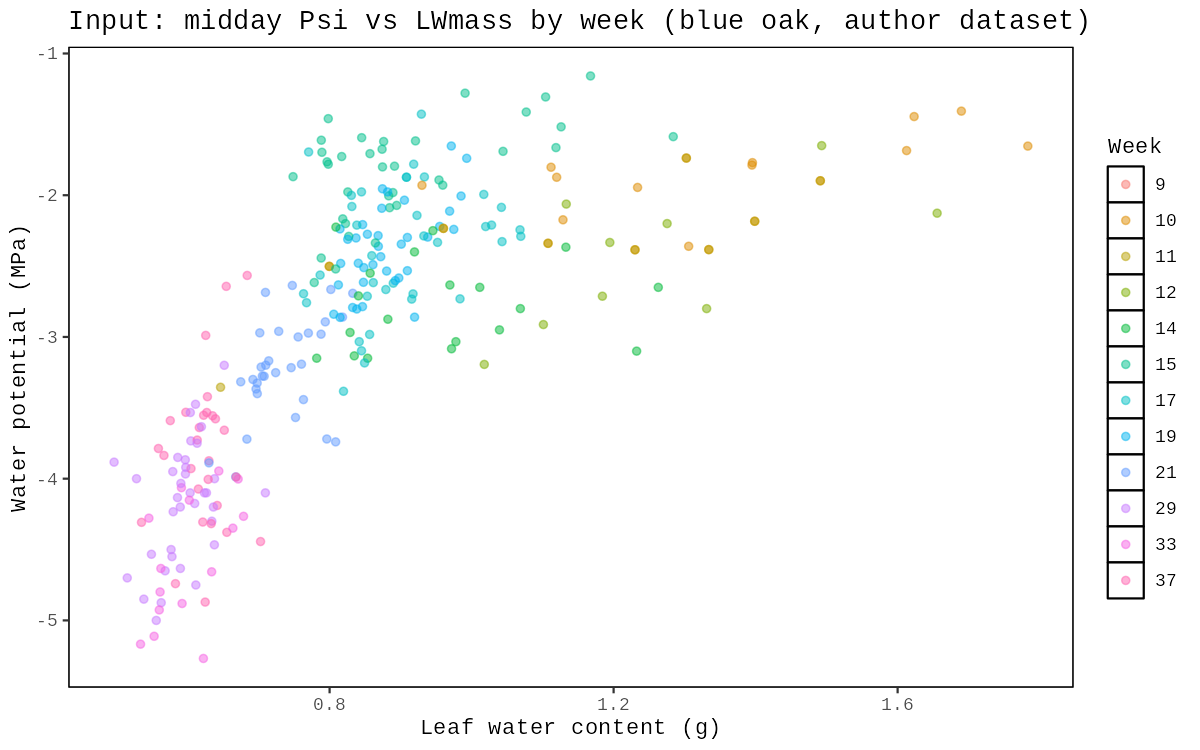

In [ ]:
%%time
r_data = r"""
library(tidyverse); library(janitor); library(lubridate)
# --- author figure theme, verbatim from scripts/scripts_functions/figure_info.R (v2.0); sourced after tidyverse so ggplot scales resolve ---
source("/content/scripts/scripts_functions/figure_info.R")
select <- dplyr::select
set.seed(2025)  # added: deterministic bootstrap rounds (author loops are unseeded)

# --- author chunk (3.1_BLUES_LWC.Rmd, data-loading chunk 1) — only here::here() path adapted ---
data_qudo_raw <-  read_csv("/content/processed-data/analysis_bothspp20230724.csv")  %>%
  filter(species %in% c("blue oak")) %>%
  distinct() %>%
  mutate(time_season = case_when(
    week  <= 17 ~ "before leafout",
    week > 17 ~ "after leafout",
    TRUE ~ as.character("none")
  )) %>%
    mutate(week = case_when(
    date_wp %in% c("2022-03-15") ~ 11,
    TRUE ~ as.numeric(week)
  )) %>%
  filter(!(date_wp %in% c("2022-04-04") & time %in% c("md"))) %>%
  select(-plot) %>%
  distinct() %>%
  filter(!(week == 19 & time == "pd" & water_potential < -2))

wc_qudo_df <- data_qudo_raw %>%
  select(tree, week, water_potential, lwc_mean, time_season, time, species, site, date_wp) %>%
  distinct()

cat("rows:", nrow(wc_qudo_df), " trees:", length(unique(wc_qudo_df$tree)),
    " weeks:", length(unique(wc_qudo_df$week)), "\n")
print(wc_qudo_df %>% count(week, time) %>% pivot_wider(names_from = time, values_from = n))

# author input preview (chunk 5 opening plot)
p_prev <- wc_qudo_df %>%
  filter(time == "md") %>%
  ggplot(aes(y = water_potential, x = lwc_mean, color = as.factor(week))) +
  geom_point(alpha = .5) +
  labs(y = "Water potential (MPa)", x = "Leaf water content (g)", color = "Week",
       title = "Input: midday Psi vs LWmass by week (blue oak, author dataset)")
ggsave("/content/input_preview.png", p_prev, width = 8, height = 5, dpi = 150)
saveRDS(wc_qudo_df, "/content/wc_qudo_df.rds")
"""
open('/content/step_data.R','w').write(r_data)
run_r('/content/step_data.R')
from IPython.display import Image
Image('/content/input_preview.png')

## 5 · Diel ("hydration, individual trees") slopes

Author's diel analysis: for each sampling week, fit `lm(water_potential ~ lwc_mean)` **per tree** (midday + predawn rows), then resample 39 trees with replacement for 1000 rounds; per round take the mean of the sampled per-tree slopes; report the mean and 2.5/97.5 % quantiles per week. Excluded tree-weeks follow the author's chunk verbatim. The only change is performance-only: slopes are collected in a list and bound once instead of `bind_rows` inside the loop (identical arithmetic).

**日本語:** 週ごとに樹木単位の回帰傾きを求め、39 樹の再サンプリングを 1000 回行い平均傾きと 95% 区間を推定します（作者コードをそのまま使用、高速化のため行の蓄積方法のみ変更）。

In [ ]:
%%time
open('/content/step_diel.R','w').write(r"""
library(tidyverse)
wc_qudo_df <- readRDS("/content/wc_qudo_df.rds")
n_iterations <- 1000
n_sample_trees <- 39

# --- author chunk: diel dataset with excluded tree-weeks (verbatim) ---
data <- wc_qudo_df %>%
  select(tree, week, water_potential, lwc_mean, time) %>%
  drop_na(lwc_mean, water_potential) %>%
  group_by(tree, week) %>%
  filter(all(c("pd", "md") %in% time)) %>%
  ungroup() %>%
  distinct() %>%
  filter(!(week == 17 & tree %in% c(2010, 2379))) %>%
  filter(!(week == 15 & tree %in% c(2009))) %>%
  filter(!(week == 33 & tree %in% c(2379, 2378)))%>%
  filter(!(week == 29 & tree %in% c(2006, 2086)))

calculate_slope_for_tree <- function(tree_data) {
  model <- lm(water_potential ~ lwc_mean, data = tree_data)
  return(coef(model)[2])
}

rows <- list(); k <- 0
for (x in unique(data$week)) {
  week_data <- data %>% filter(week == x)
  for (i in 1:n_iterations) {
    sampled_tree_ids <- sample(unique(week_data$tree), size = n_sample_trees, replace = TRUE)
    for (tree_id in sampled_tree_ids) {
      tree_data <- week_data %>% filter(tree == tree_id)
      k <- k + 1
      rows[[k]] <- data.frame(tree = tree_id,
                              slope = calculate_slope_for_tree(tree_data),
                              round = i, week = x)
    }
  }
}
bootstrapped_slopes_df <- bind_rows(rows)
cat("diel bootstrap rows:", nrow(bootstrapped_slopes_df), "\n")

# author summary (verbatim)
summary_df_hyd <- bootstrapped_slopes_df %>%
  drop_na(slope) %>%
  group_by(week, round) %>%
  mutate(slope_round = mean(slope, na.rm = T)) %>%
  ungroup() %>%
  group_by(week) %>%
  mutate(mean_slope = mean(slope_round, na.rm = T),
         lower_bound = quantile(slope_round, 0.025, na.rm = TRUE),
         upper_bound = quantile(slope_round, 0.975, na.rm = TRUE)) %>%
  select(week, mean_slope, lower_bound, upper_bound) %>%
  distinct()
print(as.data.frame(summary_df_hyd))
saveRDS(summary_df_hyd, "/content/summary_df_hyd.rds")
""")
run_r('/content/step_diel.R')

diel bootstrap rows: 429000 
   week mean_slope lower_bound upper_bound
1    17  17.969073  11.7918246    23.91471
2    21  14.548262  11.4979000    17.95074
3    37  19.094273  10.7574754    29.01752
4    10   7.937391   2.4410280    14.11792
5    29  18.124563   6.8948302    29.40013
6    12   9.179281   6.8656968    11.66215
7    14   8.922932   7.4011297    10.54675
8    19  10.828657   8.0108146    13.48568
9    33  19.150010   6.1963936    31.95935
10   15   7.860186  -1.2855852    17.17894
11   11   8.992160   0.8297922    17.28934
CPU times: user 49.6 ms, sys: 14.3 ms, total: 63.9 ms
Wall time: 19min 39s


## 6 · Spatial slopes

Author's spatial analysis (midday rows only): within each week, bootstrap **rows** with replacement 1000 times, fit `lm(water_potential ~ lwc_mean)` on each resample, and report the mean slope and 2.5/97.5 % quantiles per week. This is the "space" curve that the paper shows never approaches the diel or PV slopes.

**日本語:** 各週内で行単位のブートストラップ（1000 回）により空間的な Ψ–含水量傾きを推定します。

In [ ]:
%%time
open('/content/step_space.R','w').write(r"""
library(tidyverse)
wc_qudo_df <- readRDS("/content/wc_qudo_df.rds")
n_iterations <- 1000

# --- author chunk (spatial, verbatim) ---
data <- wc_qudo_df %>%
  filter(time == "md") %>%
  select(tree, week, water_potential, lwc_mean) %>%
  distinct() %>%
  drop_na(lwc_mean, water_potential)

final_df_space <- data.frame(week = integer(), mean_slope = numeric(), lower_bound = numeric(), upper_bound = numeric())
for (x in unique(data$week)) {
  week_data <- data %>% filter(week == x)
  slopes <- vector("double", length = n_iterations)
  for (i in 1:n_iterations) {
    boot_indices <- sample(nrow(week_data), replace = TRUE)
    boot_sample <- week_data[boot_indices, ]
    model <- lm(water_potential ~ lwc_mean, data = boot_sample)
    slopes[i] <- coef(model)[2]
  }
  final_df_space <- bind_rows(final_df_space, data.frame(week = x,
        mean_slope = mean(slopes),
        lower_bound = quantile(slopes, 0.025, na.rm = T),
        upper_bound = quantile(slopes, 0.975, na.rm = T)))
}
print(as.data.frame(final_df_space))
saveRDS(final_df_space, "/content/final_df_space.rds")
""")
run_r('/content/step_space.R')

week mean_slope lower_bound upper_bound
2.5%...1    15  1.4996068  0.79126758    2.358832
2.5%...2    17  1.6120232  0.21997467    3.113498
2.5%...3    19  3.3230339  1.92849287    4.755773
2.5%...4    21  3.1731672  0.03746585    5.520716
2.5%...5    29  4.2455146  0.85444264    8.773557
2.5%...6    37  3.0112138 -3.13027436    9.542324
2.5%...7    10  0.8174235  0.39565166    1.169363
2.5%...8    12  1.6766721  0.13866673    3.422963
2.5%...9    14  0.1973875 -0.86144600    1.277029
2.5%...10   33  4.7683855  1.20133568    8.066540
2.5%...11   11  1.1546738  0.28416751    1.885206
CPU times: user 1.58 ms, sys: 1.09 ms, total: 2.68 ms
Wall time: 12.4 s


## 7 · Seasonal (temporal) slopes

Author's temporal analysis: keep midday rows of trees measured **both before and after leaf expansion**, then bootstrap 40 trees (with replacement, 1000 rounds) over pre-leafout weeks (10–17) and post-leafout weeks (18–40) separately, giving one "before leafout" and one "after leafout" slope. Plotly display chunks from the author notebook are omitted (headless run).

**日本語:** 展開前・展開後の両方に測定された樹木に限定し、展開前（週 10–17）と展開後（週 18–40）で 40 樹 ×1000 回のブートストラップを行い季節変化に沿った傾きを推定します。

In [ ]:
%%time
open('/content/step_time.R','w').write(r"""
library(tidyverse)
wc_qudo_df <- readRDS("/content/wc_qudo_df.rds")
n_iterations <- 1000
n_sample_trees <- 40
calculate_slope_for_tree <- function(tree_data) {
  model <- lm(water_potential ~ lwc_mean, data = tree_data)
  return(coef(model)[2])
}

# --- author chunk (temporal, verbatim minus plotly display) ---
data_all <- wc_qudo_df %>% filter(time == "md")
before_leafout_data <- data_all %>% filter(time_season == "before leafout")
after_leafout_data  <- data_all %>% filter(time_season == "after leafout")
common_trees <- intersect(before_leafout_data$tree, after_leafout_data$tree)
common_trees_data <- data_all %>% filter(tree %in% common_trees)
cat("Number of unique tree IDs in common_trees_data:", length(unique(common_trees_data$tree)), "\n")
filtered_data <- data_all[data_all$tree %in% common_trees, ]

run_temporal <- function(data, label) {
  rows <- list(); k <- 0
  for (i in 1:n_iterations) {
    sampled_tree_ids <- sample(unique(data$tree), size = n_sample_trees, replace = TRUE)
    for (tree_id in sampled_tree_ids) {
      tree_data <- data %>% filter(tree == tree_id)
      k <- k + 1
      rows[[k]] <- data.frame(tree = tree_id, slope = calculate_slope_for_tree(tree_data), round = i)
    }
  }
  bootstrapped_slopes_df <- bind_rows(rows)
  ci_values <- bootstrapped_slopes_df %>%
    group_by(round) %>% drop_na(slope) %>%
    mutate(mean_slope_round = mean(slope, na.rm = T)) %>% ungroup() %>%
    mutate(mean = mean(mean_slope_round, na.rm = T),
           lower_bound = quantile(mean_slope_round, 0.025, na.rm = TRUE),
           upper_bound = quantile(mean_slope_round, 0.975, na.rm = TRUE))
  ci_values %>% mutate(mean_slope = mean(mean, na.rm = T), pre_post = label) %>%
    select(mean_slope, lower_bound, upper_bound, pre_post) %>% distinct()
}

data <- filtered_data %>% filter(week %in% c(10:17)) %>% distinct() %>% drop_na(water_potential, lwc_mean)
mean_slope_before <- run_temporal(data, "before leafout")
data <- common_trees_data %>% filter(week %in% c(18:40)) %>%
  select(tree, week, water_potential, lwc_mean) %>% distinct() %>% drop_na(water_potential, lwc_mean)
mean_slope_after <- run_temporal(data, "after leafout")

time_boot_df <- bind_rows(mean_slope_before, mean_slope_after) %>%
  select(pre_post, mean_slope, lower_bound, upper_bound) %>% distinct() %>%
  mutate(analysis = "time, ind. tree")
print(as.data.frame(time_boot_df))
saveRDS(time_boot_df, "/content/time_boot_df.rds")
""")
run_r('/content/step_time.R')

Number of unique tree IDs in common_trees_data: 40 
        pre_post mean_slope lower_bound upper_bound        analysis
1 before leafout -0.2353612   -2.412347    1.956365 time, ind. tree
2  after leafout  6.4689110    5.952553    7.014232 time, ind. tree
CPU times: user 10.6 ms, sys: 3.67 ms, total: 14.3 ms
Wall time: 3min 33s


## 8 · Laboratory pressure–volume (PV) curve slopes

Author's PV pipeline from `1_pvcurves.Rmd`: process the two PV tables (`pv_shift_kk.csv` for 2022 curves, `pv_curves_long_rayna.csv` for the July 2023 survey) exactly as authored — `lwc = fresh_mass/dry_mass` (kk) and `lwc = lw_g/dry_weight` (rr) — combine, drop `rehydrated == "no"`, remap two dates as the authors do, then bootstrap per-curve slopes `lm(water_potential ~ lwc)` for each PV campaign (2022-03-30, 2022-04-05, 2022-05-24, 2023-07-27) with the author's per-campaign sample sizes (6, 3, 4, 20 curves).

**日本語:** PV 曲線データを作者の処理式そのままで整形し、各キャンペーンの曲線単位の傾きをブートストラップします。

In [ ]:
%%time
open('/content/step_pv.R','w').write(r"""
library(tidyverse); library(janitor); library(lubridate)
set.seed(2025)
n_iterations <- 1000
calculate_slope_for_tree <- function(tree_data) {
  model <- lm(water_potential ~ lwc, data = tree_data)
  return(coef(model)[2])
}
run_pv <- function(data, n_sample_trees, label) {
  rows <- list(); k <- 0
  for (i in 1:n_iterations) {
    sampled_tree_ids <- sample(unique(data$tree), size = n_sample_trees, replace = TRUE)
    for (tree_id in sampled_tree_ids) {
      tree_data <- data %>% filter(tree == tree_id)
      k <- k + 1
      rows[[k]] <- data.frame(tree = tree_id, slope = calculate_slope_for_tree(tree_data), round = i)
    }
  }
  bootstrapped_slopes_df <- bind_rows(rows)
  ci_values <- bootstrapped_slopes_df %>%
    group_by(round) %>% drop_na(slope) %>%
    mutate(mean_slope_round = mean(slope, na.rm = T)) %>% ungroup() %>%
    mutate(mean = mean(mean_slope_round, na.rm = T),
           lower_bound = quantile(mean_slope_round, 0.025, na.rm = TRUE),
           upper_bound = quantile(mean_slope_round, 0.975, na.rm = TRUE))
  ci_values %>% mutate(mean_slope = mean(mean, na.rm = T), pre_post = label) %>%
    select(mean_slope, lower_bound, upper_bound, pre_post) %>% distinct()
}

# --- author chunks (verbatim): 2022 PV curves (kk) ---
pv_new_kk_raw <- read_csv("/content/final_data/pv_shift_kk.csv", show_col_types = FALSE) %>%
  clean_names() %>%
  mutate(lwc = fresh_mass/dry_mass,
         lma = dry_mass/leaf_area,
         lwa = lwc*lma,
         rwc = fresh_mass/fresh_mass_saturated,
         rwd = 1 - rwc,
         swc = fresh_mass_saturated/dry_mass) %>%
  unite("unique_id", c(date, sample, rep), sep = "_", remove = F) %>%
  filter(species == "blue") %>%
  mutate(date = mdy(date))
pv_new_kk_df <- pv_new_kk_raw %>%
  select(unique_id, date, water_potential, lwc, lma, lwa, rwc, rwd, swc) %>%
  mutate(week = week(date)) %>%
  filter(rwc < 1, rwc > 0.75) %>%
  filter(!date %in% c("2022-05-03", "2022-05-04"))

# --- author chunks (verbatim): 2023 PV curves (rayna) ---
pv_new_rr_raw <- read_csv("/content/final_data/pv_curves_long_rayna.csv", show_col_types = FALSE) %>%
  clean_names() %>%
  group_by(date, tree, rehydrated, pd_or_md) %>%
  fill(c(stem_dry_wt_g, leaves_dry_wt_g, total_nonsample_wt, leaf_area), .direction = "downup") %>%
  ungroup() %>%
  mutate(total_nonsample_wt = case_when(total_nonsample_wt %in% c(NA_real_) ~ 0, TRUE ~ as.numeric(total_nonsample_wt))) %>%
  mutate(stem_dry_wt_g = case_when(stem_dry_wt_g %in% c(NA_real_) ~ 0, TRUE ~ as.numeric(stem_dry_wt_g))) %>%
  mutate(fresh_mass = mass_g - total_nonsample_wt,
         dry_mass = leaves_dry_wt_g + stem_dry_wt_g,
         water_potential = mpa) %>%
  mutate(lwc = mass_g/dry_mass, lma = dry_mass/leaf_area, lwa = lwc*lma,
         rwc = fresh_mass/swc, rwd = 1 - rwc) %>%
  unite("unique_id", c(date, tree, rehydrated, pd_or_md), sep = "_", remove = F) %>%
  mutate(date = mdy(date))
pv_new_rr_df <- pv_new_rr_raw %>%
  select(unique_id, date, water_potential, lwc, lma, lwa, rwc, rwd, swc, rehydrated) %>%
  mutate(week = week(date)) %>%
  filter(date %in% c("2023-07-27"))

# --- author chunk (verbatim): combine ---
pv_new_df <- bind_rows(pv_new_kk_df, pv_new_rr_df) %>%
  filter(!(rehydrated %in% c("no"))) %>%
  mutate(date = case_when(
    date %in% c("2022-04-01") ~ as.Date("2022-03-30"),
    date %in% c("2022-04-07") ~ as.Date("2022-04-05"),
    TRUE ~ as.Date(date)))
cat("PV curves per campaign:\\n"); print(table(as.character(pv_new_df$date)))

d1 <- pv_new_df %>% filter(date %in% c("2022-03-30", "2022-04-01")) %>% distinct() %>% drop_na(water_potential, lwc) %>% mutate(tree = unique_id)
mean_slope_220330 <- run_pv(d1, 6, "2022-03-30")
d2 <- pv_new_df %>% filter(date %in% c("2022-04-07", "2022-04-05")) %>% distinct() %>% drop_na(water_potential, lwc) %>% mutate(tree = unique_id)
mean_slope_220407 <- run_pv(d2, 3, "2022-04-05")
d3 <- pv_new_df %>% filter(date %in% c("2022-05-24")) %>% distinct() %>% drop_na(water_potential, lwc) %>% mutate(tree = unique_id)
mean_slope_220504 <- run_pv(d3, 4, "2022-05-24")
d4 <- pv_new_df %>% filter(date %in% c("2023-07-27")) %>% distinct() %>% drop_na(water_potential, lwc) %>% mutate(tree = unique_id) %>% filter(!(lma == 0))
mean_slope_230727 <- run_pv(d4, 20, "2023-07-27")

# --- author chunk (verbatim): combine PV results ---
pv_boot_df <- bind_rows(mean_slope_220330, mean_slope_220407, mean_slope_220504, mean_slope_230727) %>%
  select(pre_post, mean_slope, lower_bound, upper_bound) %>% distinct() %>%
  mutate(analysis = "pv curves") %>%
  mutate(slope = mean_slope, upr = as.numeric(upper_bound), lwr = as.numeric(lower_bound), pre_post = ymd(pre_post))
print(as.data.frame(pv_boot_df))
saveRDS(pv_boot_df, "/content/pv_boot_df.rds")
""")
run_r('/content/step_pv.R')

PV curves per campaign:\n
2022-03-30 2022-04-05 2022-05-24 2023-07-27 
        54         63         67        207 
    pre_post mean_slope lower_bound upper_bound  analysis    slope      upr
1 2022-03-30   12.33926    7.885462    17.24788 pv curves 12.33926 17.24788
2 2022-04-05   11.90582    5.877914    18.43364 pv curves 11.90582 18.43364
3 2022-05-24   11.66853    6.471375    16.96182 pv curves 11.66853 16.96182
4 2023-07-27   20.08502   17.945762    22.32638 pv curves 20.08502 22.32638
        lwr
1  7.885462
2  5.877914
3  6.471375
4 17.945762
CPU times: user 4.22 ms, sys: 1.45 ms, total: 5.67 ms
Wall time: 1min 33s


## 9 · Mixed-effects model (Table 2 family)

Fit the author's full random-slopes model on all blue-oak rows: `lmer(water_potential ~ lwc_mean + (lwc_mean|tree) + (lwc_mean|week) + (1|site), REML = TRUE)`. The fixed-effect `lwc_mean` coefficient is the population-average Ψ–LWmass slope that the bootstrap analyses unpack by scale. **日本語:** 作者の混合モデルをそのまま当てはめ、固定効果の傾きを確認します。

In [ ]:
%%time
open('/content/step_mixed.R','w').write(r"""
library(tidyverse); library(lme4)
wc_qudo_df <- readRDS("/content/wc_qudo_df.rds")
wk_all <- wc_qudo_df %>% mutate(site = as.factor(site))
wk_all_sites <- wk_all %>% drop_na(site)
m_wk_rand_site <- lmer(water_potential ~ lwc_mean + (lwc_mean|tree) + (lwc_mean|week) + (1|site), data = wk_all_sites, REML = T)
print(summary(m_wk_rand_site)$coefficients)
saveRDS(m_wk_rand_site, "/content/m_wk_rand_site.rds")
""")
run_r('/content/step_mixed.R')

Estimate Std. Error   t value
(Intercept) -4.870442  0.7756480 -6.279191
lwc_mean     3.421767  0.8796522  3.889909
CPU times: user 100 µs, sys: 2.75 ms, total: 2.85 ms
Wall time: 3.7 s


## 10 · Results: slope comparison figure and table

Assemble the author's result tables exactly as `3.1_BLUES_LWC.Rmd` does (`bootstrapped_df_qudo_lwc_mean.csv` contents) plus the PV slopes, and draw the four-panel slope comparison in the author's geom structure (segment = 95 % CI, point = mean slope). The x-axes: sampling week (diel), sampling week (spatial), leaf-expansion window (temporal), and PV campaign date. The paper's finding to look for: the diel and PV slopes broadly agree and steepen after leaf expansion, while the spatial slopes stay shallow and diverge.

**日本語:** 4 パネルの傾き比較図（各点=平均傾き、線分=95% CI）と結果表を作成します。展開後は diel と PV がほぼ一致し、空間傾きは浅いままであることが論文の主張です。

5  hydration, ind. trees   29             NA 18.125  6.895 29.400
6  hydration, ind. trees   12             NA  9.179  6.866 11.662
7  hydration, ind. trees   14             NA  8.923  7.401 10.547
8  hydration, ind. trees   19             NA 10.829  8.011 13.486
9  hydration, ind. trees   33             NA 19.150  6.196 31.959
10 hydration, ind. trees   15             NA  7.860 -1.286 17.179
11 hydration, ind. trees   11             NA  8.992  0.830 17.289
12                 space   15             NA  1.500  0.791  2.359
13                 space   17             NA  1.612  0.220  3.113
14                 space   19             NA  3.323  1.928  4.756
15                 space   21             NA  3.173  0.037  5.521
16                 space   29             NA  4.246  0.854  8.774
17                 space   37             NA  3.011 -3.130  9.542
18                 space   10             NA  0.817  0.396  1.169
19                 space   12             NA  1.677  0.139  3.423
20        

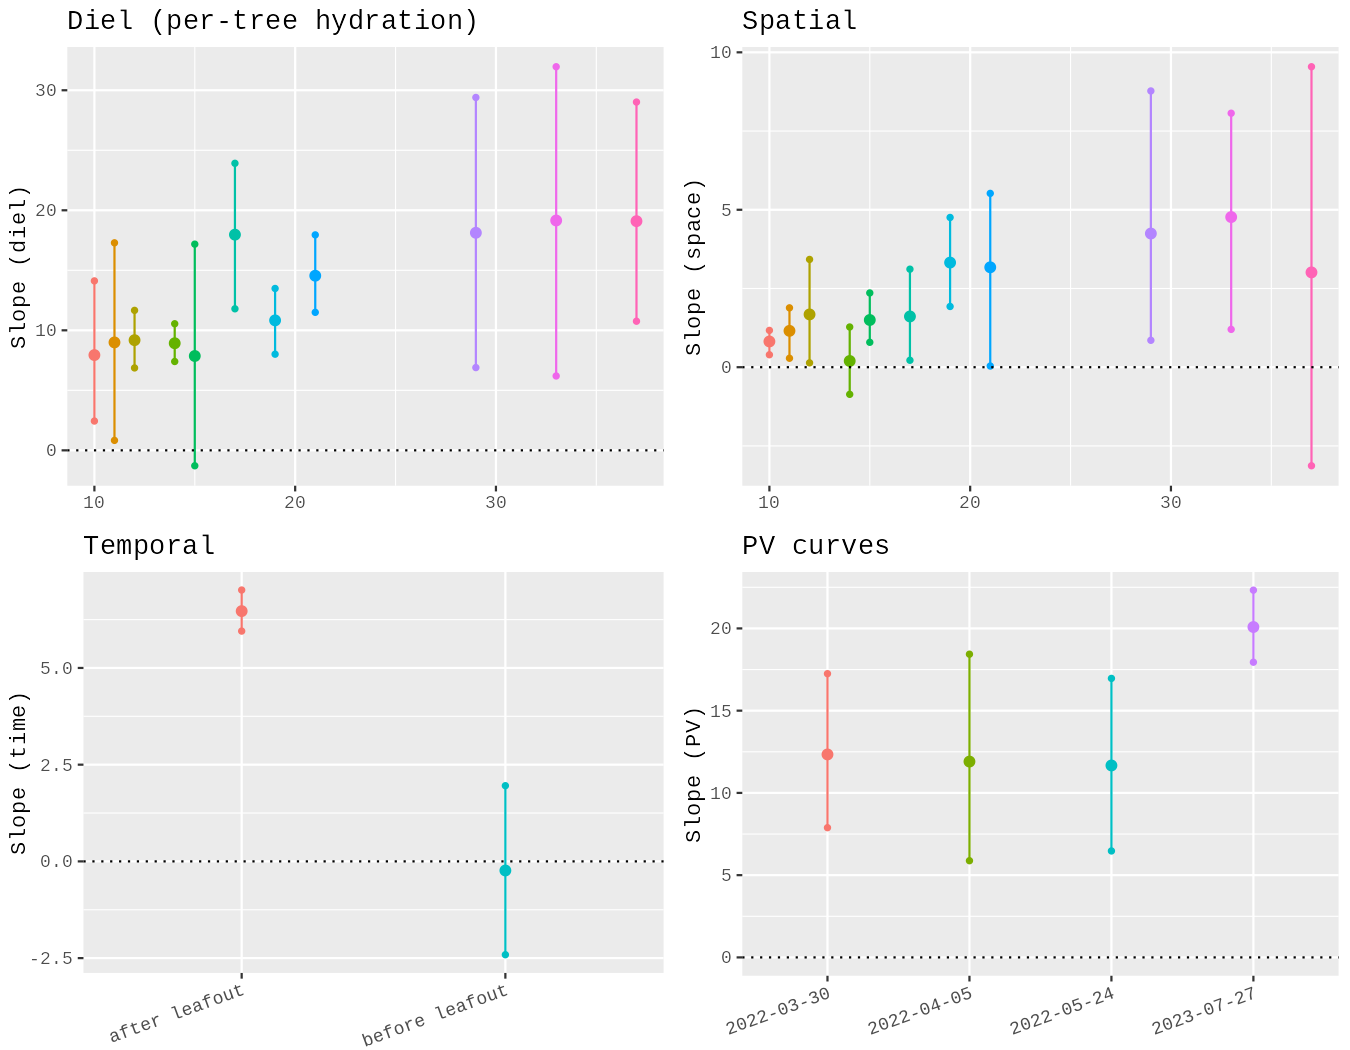

In [ ]:
%%time
open('/content/step_final.R','w').write(r"""
library(tidyverse); library(gridExtra)
summary_df_hyd  <- readRDS("/content/summary_df_hyd.rds")
final_df_space  <- readRDS("/content/final_df_space.rds")
time_boot_df    <- readRDS("/content/time_boot_df.rds")
pv_boot_df      <- readRDS("/content/pv_boot_df.rds")

# --- author assembly (verbatim) ---
final_df_hyd <- summary_df_hyd %>% mutate(analysis = "hydration, ind. trees", time_season = "NA")
final_df_space <- final_df_space %>% mutate(analysis = "space", time_season = "NA")
time_boot_df2 <- time_boot_df %>% mutate(week = 0, time_season = pre_post)
final_df_all <- bind_rows(final_df_hyd, final_df_space, time_boot_df2) %>%
  mutate(slope = mean_slope, lwr = lower_bound, upr = upper_bound)
write_csv(final_df_all, "/content/bootstrapped_df_qudo_lwc_mean.csv")
write_csv(pv_boot_df, "/content/pv_slopes_recomputed.csv")

seg <- function(df, xq, ylab) df %>%
  ggplot(aes(color = as.factor({{xq}}))) +
  geom_point(aes(y = slope, x = {{xq}}), size = 2) +
  geom_point(aes(y = upr, x = {{xq}}), size = 1) +
  geom_point(aes(y = lwr, x = {{xq}}), size = 1) +
  geom_segment(aes(y = lwr, yend = upr, x = {{xq}}, xend = {{xq}})) +
  geom_hline(yintercept = 0, linetype = "dotted") +
  labs(y = ylab, x = NULL, color = NULL) + theme(legend.position = "none")

p1 <- seg(final_df_all %>% filter(analysis == "hydration, ind. trees", week != 0), week, "Slope (diel)") +
      labs(title = "Diel (per-tree hydration)")
p2 <- seg(final_df_all %>% filter(analysis == "space"), week, "Slope (space)") +
      labs(title = "Spatial")
p3 <- seg(time_boot_df %>% mutate(slope = mean_slope, lwr = lower_bound, upr = upper_bound), pre_post, "Slope (time)") +
      labs(title = "Temporal") + theme(axis.text.x = element_text(angle = 20, hjust = 1))
p4 <- seg(pv_boot_df, as.character(pre_post), "Slope (PV)") +
      labs(title = "PV curves") + theme(axis.text.x = element_text(angle = 20, hjust = 1))
g <- arrangeGrob(p1, p2, p3, p4, ncol = 2)
ggsave("/content/fig2_slopes.png", g, width = 9, height = 7, dpi = 150)

cat("--- Result table: bootstrapped slopes (mean, 95% CI) ---\\n")
print(as.data.frame(final_df_all %>% select(analysis, week, time_season, slope, lwr, upr) %>%
      mutate(across(where(is.numeric), ~round(., 3)))))
cat("--- PV slopes ---\\n")
print(as.data.frame(pv_boot_df %>% select(pre_post, slope, lwr, upr) %>% mutate(across(where(is.numeric), ~round(., 3)))))
""")
run_r('/content/step_final.R')
import shutil
shutil.copy('/content/bootstrapped_df_qudo_lwc_mean.csv','/content/results_bootstrapped_slopes.csv')
from IPython.display import Image
Image('/content/fig2_slopes.png')

## 11 · Interpretation

Read the executed outputs above against the paper's claims (Section 3.1, Figure 2):

- **Diel vs PV:** the per-tree hydration slopes (panel 1) should broadly overlap the PV-curve slopes (panel 4) — especially after leaf expansion — because a day-scale hydration cycle approximates the benchtop drydown.
- **Temporal:** the "before leafout" slope is expected to be shallower/less consistent than "after leafout" (paper: Ψ–LWmass was not significant before maturation, strong after).
- **Spatial:** the within-week slopes (panel 2) stay shallow and never approach the diel/temporal or PV slopes — the paper's core warning that "space for time" substitutions are unreliable.
- **Mixed model:** the fixed-effect `lwc_mean` slope summarizes the pooled relationship; the large random-slope SDs by tree and week are the quantitative signature of the non-stationarity.

Any quantitative agreement with published numbers is limited to this single dataset and the author's own pipeline; this run does not re-estimate paper-level statistics beyond the reproduced quantities.

**日本語:** 展開後は diel 傾きと PV 傾きが重なり、空間傾きは浅いまま留まるはずです。これは論文の主張（空間を時間の代わりに使うことの危険性）に対応します。単一データセット・作者パイプラインの再実行であり、論文全体の統計検証ではありません。

## 12 · Validation record and references

- **Validated:** fresh Colab **CPU** runtime, full notebook top-to-bottom (see report date). R version and package versions are printed by the executed cells above.
- **Provenance:** author code and data pinned to `bovingi/mpa_lwc_lwa_cwc` tag v2.0 = commit `fe5efc87404a174243dfec30631a354e0c6d1905`; Zenodo DOI 10.5281/zenodo.15110087 (CC-BY-4.0) records the same release; code license file absent in the repo root — data reuse follows the Zenodo CC-BY-4.0 terms.
- **Verbatim vs adapted:** model formulas, filters, bootstrap schemes, sample sizes, and PV processing are copied verbatim from the pinned `.Rmd` scripts. Adaptations: (1) `here::here()` paths → `/content` paths; (2) bootstrap rows collected in lists and bound once (performance only); (3) `set.seed(2025)` added for determinism (author loops unseeded); (4) plotly display chunks and unrelated analyses omitted; (5) panel styling simplified while keeping the author's geom structure.
- **Not verified here:** AVIRIS-NG CWC retrieval (ISOFIT), dCWC analysis, variance decomposition, published dataset-level statistics.
- **References:** Boving et al. 2025, GCB 31(4):e70188 (DOI 10.1111/gcb.70188; PMC12007071); code/data as above.

**日本語:** 検証は新規 CPU ランタイムでノートブック全体を通し実行して行いました。数式・ブートストラップ手法は作者の pinned スクリプトからの逐語使用で、変更点（パス、 determinstic seed、性能改善、図の簡略化）は上記に明記しています。